In [ ]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib
from sklearn.model_selection import GroupShuffleSplit

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

df = df[df['Length'] <= 500].copy()

df = df[df['Length'] <= 500].copy()

# 2. Initialize the Group Splitter
# n_splits=1 gives you a single train/test split (like train_test_split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 3. Generate the indices
# We pass the 'question_id_external' column as the 'groups' parameter
train_idx, test_idx = next(gss.split(df, groups=df['question_id_external']))

# 4. Create your new DataFrames
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)
Train shape: (3092, 27)
Test shape: (782, 27)


### Full Logistic Regression Analysis

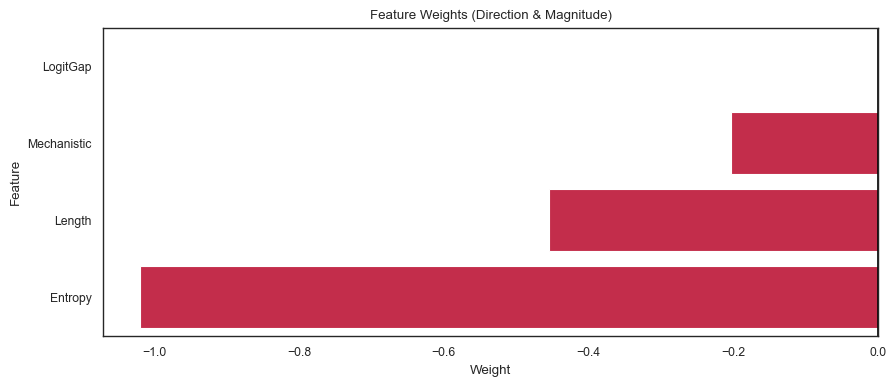

              precision    recall  f1-score   support

           0       0.41      0.63      0.50       364
           1       0.90      0.79      0.84      1572

    accuracy                           0.76      1936
   macro avg       0.65      0.71      0.67      1936
weighted avg       0.81      0.76      0.78      1936



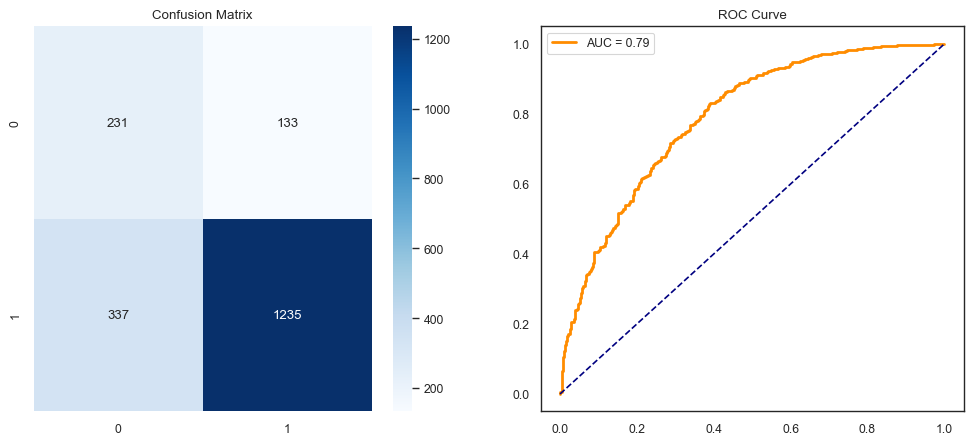

### Full Logistic Regression Analysis

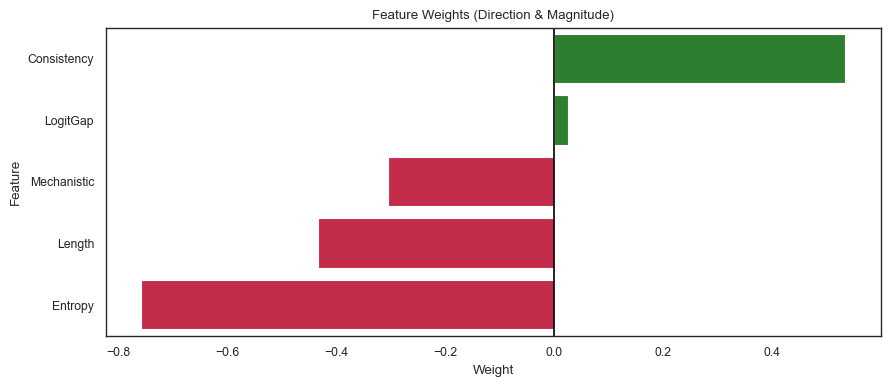

              precision    recall  f1-score   support

           0       0.41      0.65      0.50       364
           1       0.91      0.78      0.84      1572

    accuracy                           0.76      1936
   macro avg       0.66      0.72      0.67      1936
weighted avg       0.81      0.76      0.78      1936



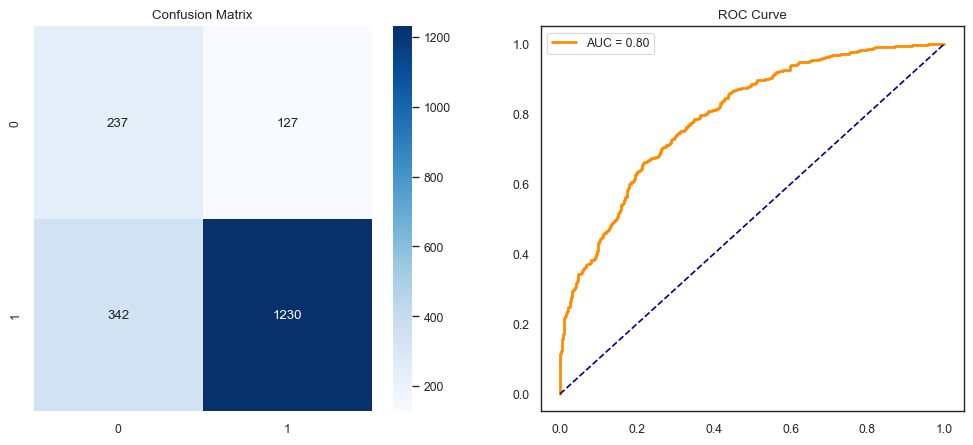

Metric,Shift (SD),Mean,SD,Vis
Entropy,+1.91 SD,0.131,0.047,
LogitGap,-0.10 SD,0.032,0.034,
Mechanistic,+1.16 SD,0.976,0.005,
Length,+0.02 SD,265.910,94.047,
Metric,Shift (SD),Mean,SD,Vis
Entropy,+0.03 SD,0.058,0.018,
LogitGap,+0.03 SD,0.043,0.041,
Mechanistic,+0.14 SD,0.967,0.005,
Length,+0.54 SD,307.863,68.973,
Metric,Shift (SD),Mean,SD,Vis


Generating t-SNE...


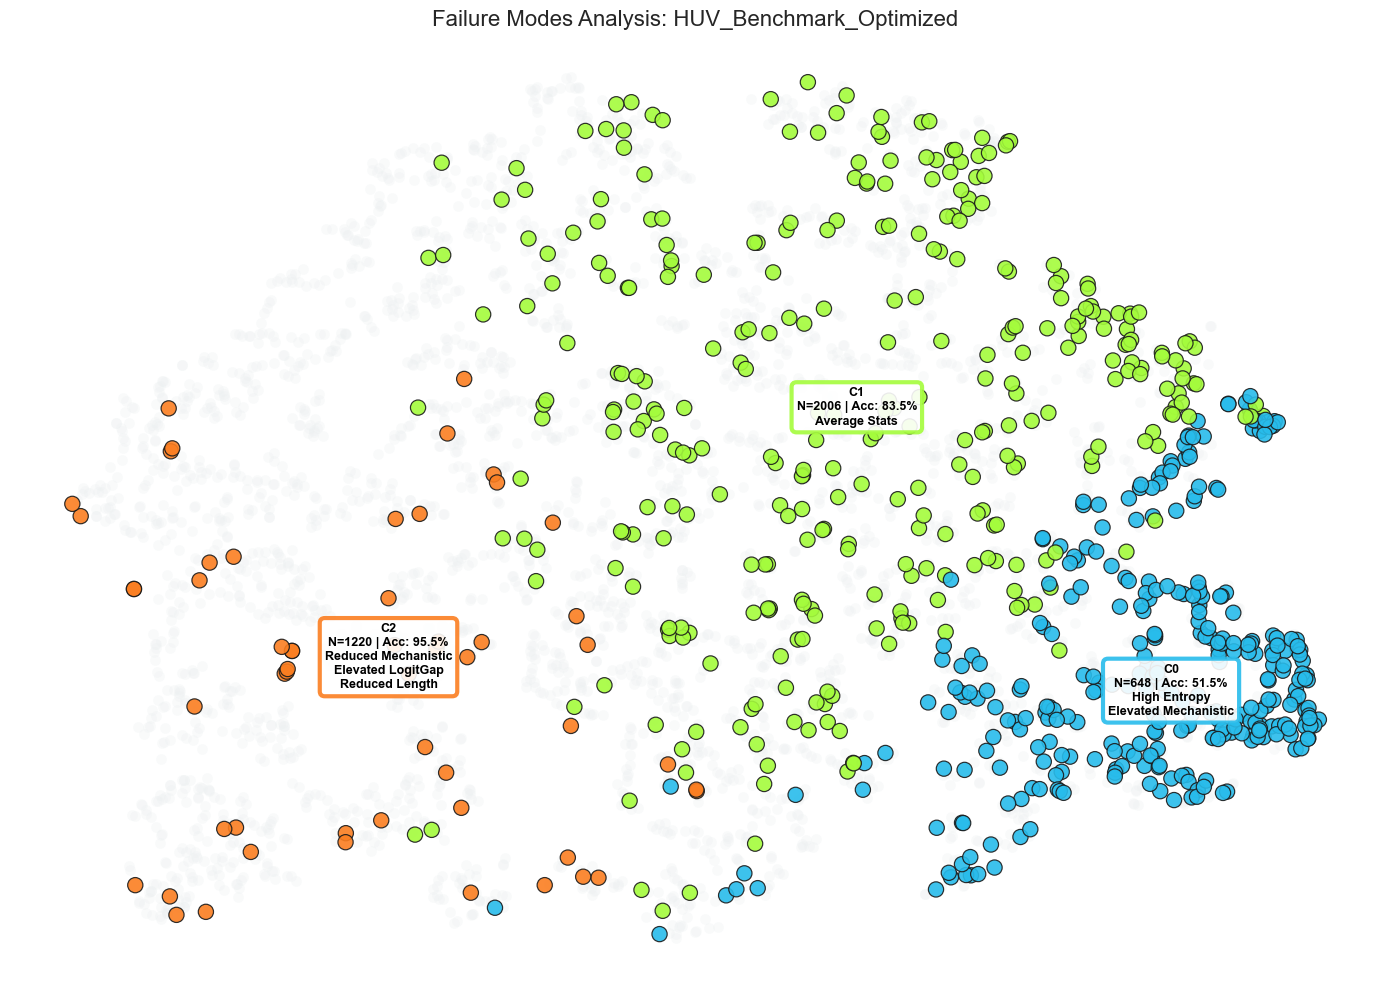

In [21]:


metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] # 'Consistency', 

logistic_predictor = utils.run_detailed_logistic_regression(df, features=metrics_to_use)

logistic_predictor_with_consistency = utils.run_detailed_logistic_regression(df, features=metrics_to_use + ["Consistency"])

cluster_predictor = utils.run_failure_modes_dashboard(df, exp_info, features=metrics_to_use)

In [22]:
# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion'], _ = logistic_predictor(df)

# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion_Consistency'], _ = logistic_predictor_with_consistency(df)

# 2. Capture Cluster Labels (Index 1)
_, df['Cluster_Label'] = cluster_predictor(df)

# 3. (Optional) Capture Cluster Confidence if needed
df['Cluster_Conf'], _ = cluster_predictor(df)

# Verify
print(df[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion                                      Cluster_Label
0         0.810163  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
1         0.894917  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
2         0.899839  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
3         0.898509  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
4         0.515271             C1\nN=2006 | Acc: 83.5%\nAverage Stats


In [23]:
utils.run_comparison_dashboard(df, logistic_predictor, cluster_predictor, metrics_to_use)

,AUROC (↑),ECE (↓),MSE (↓),Status
Model,,,,
Logistic Fusion,0.7981,0.2318,0.1745,
Cluster Baseline,0.7379,0.0000,0.1265,🏆 Winner
Entropy,0.7692,0.0368,0.1277,
LogitGap,0.3659,0.1576,0.1803,
Mechanistic,0.2445,0.1832,0.1791,
Length,0.6327,0.3419,0.2640,


Model,Mn,Rg
Logistic Fusion,0.58,0.74
Cluster Baseline,0.84,0.00
Entropy,0.87,0.26
LogitGap,0.95,0.44
Mechanistic,0.79,0.33
Length,0.41,0.77
Model,Mn,Rg
Logistic Fusion,0.79,0.59
Cluster Baseline,0.95,0.00
Entropy,0.90,0.40


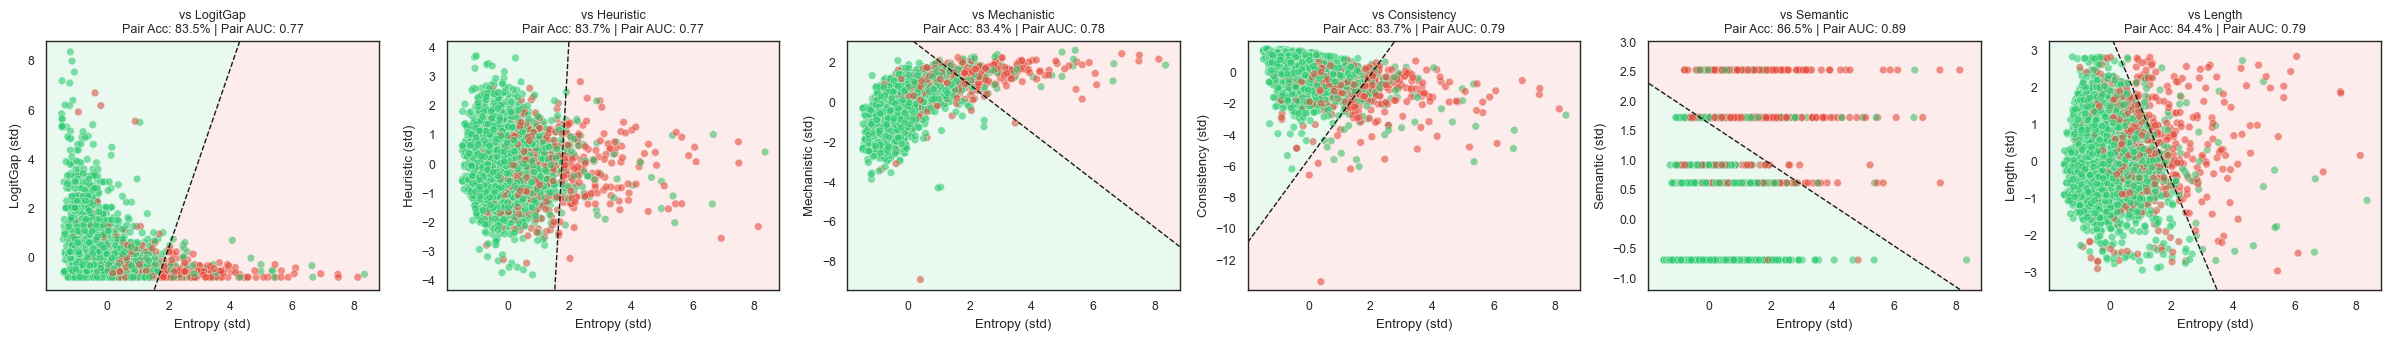

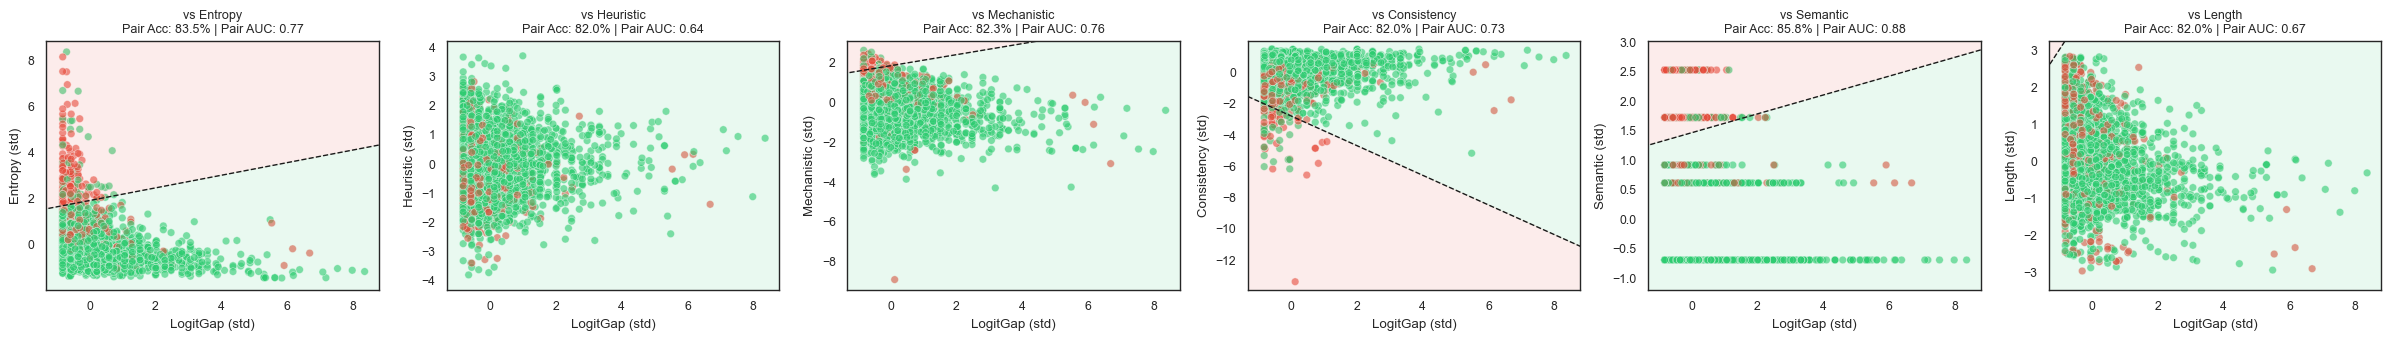

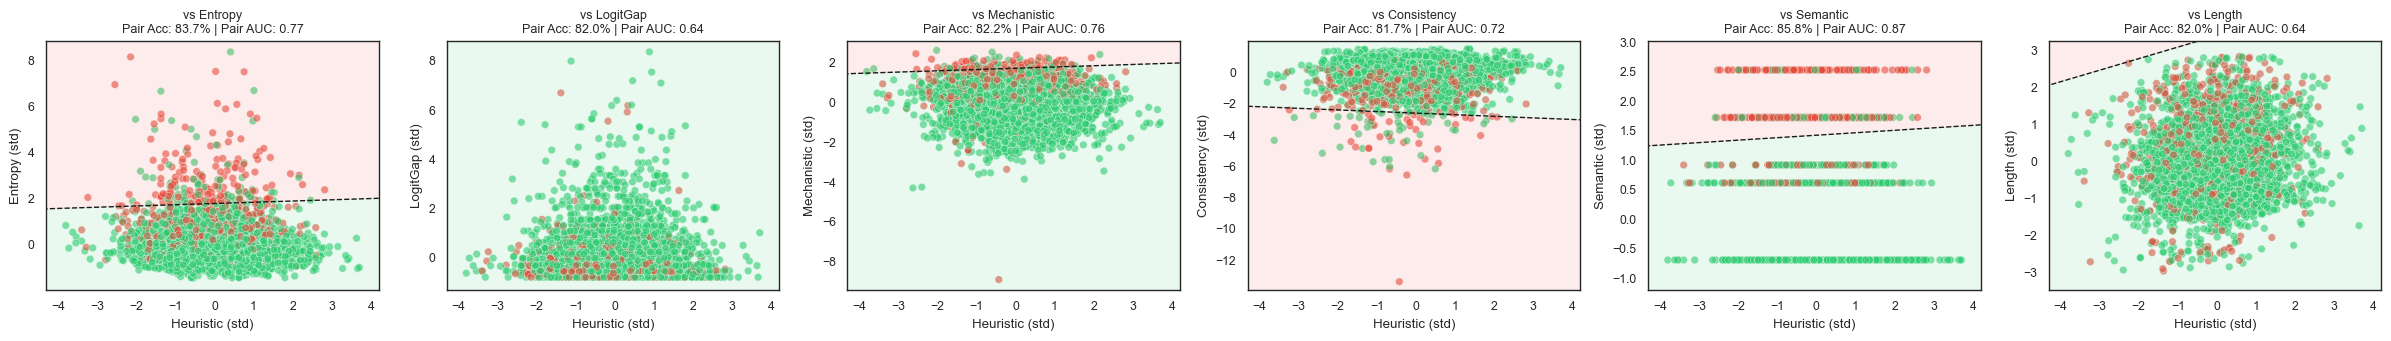

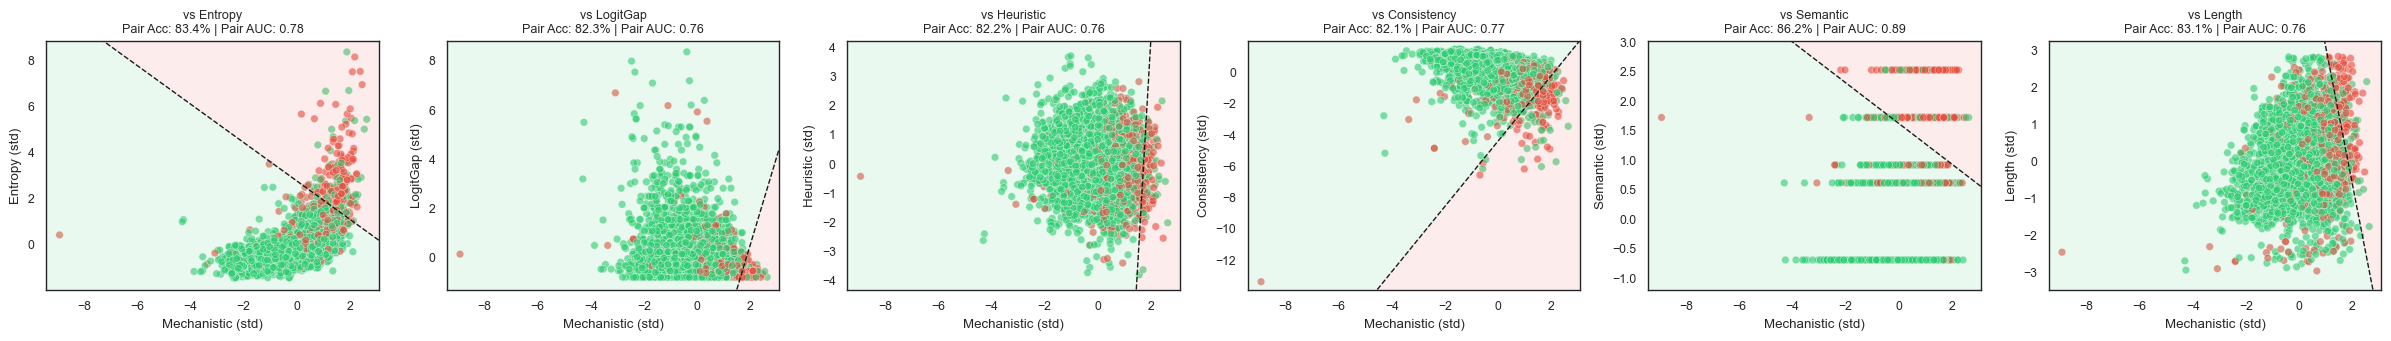

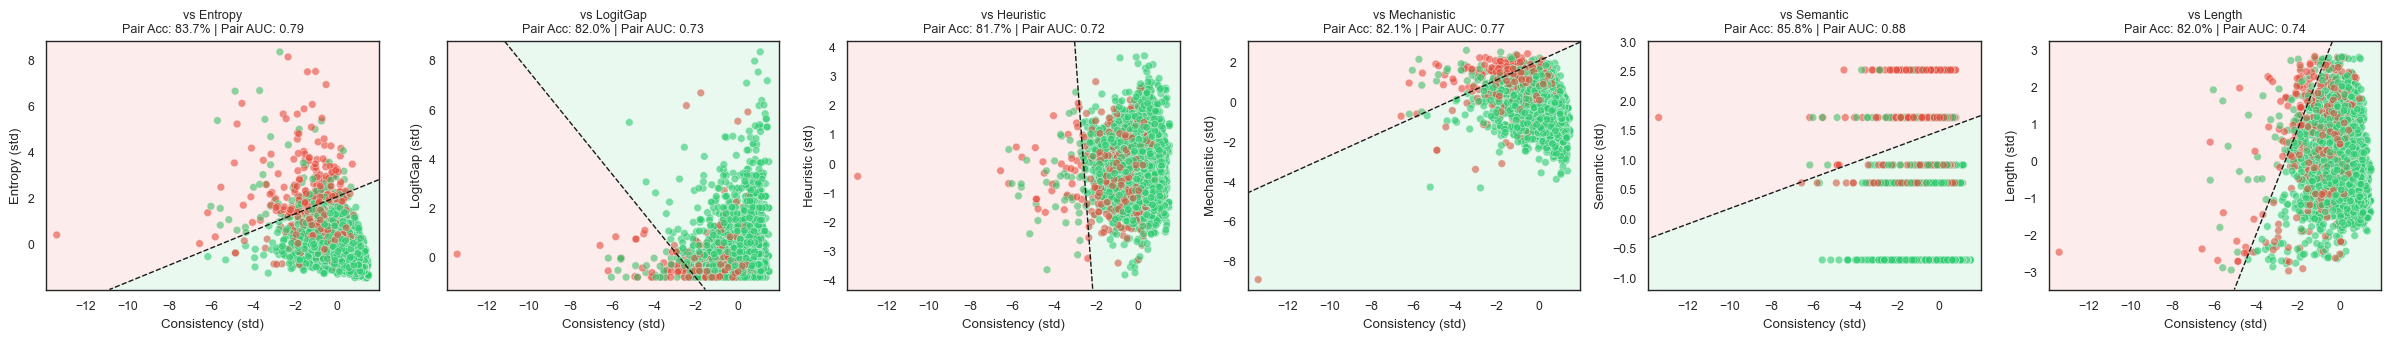

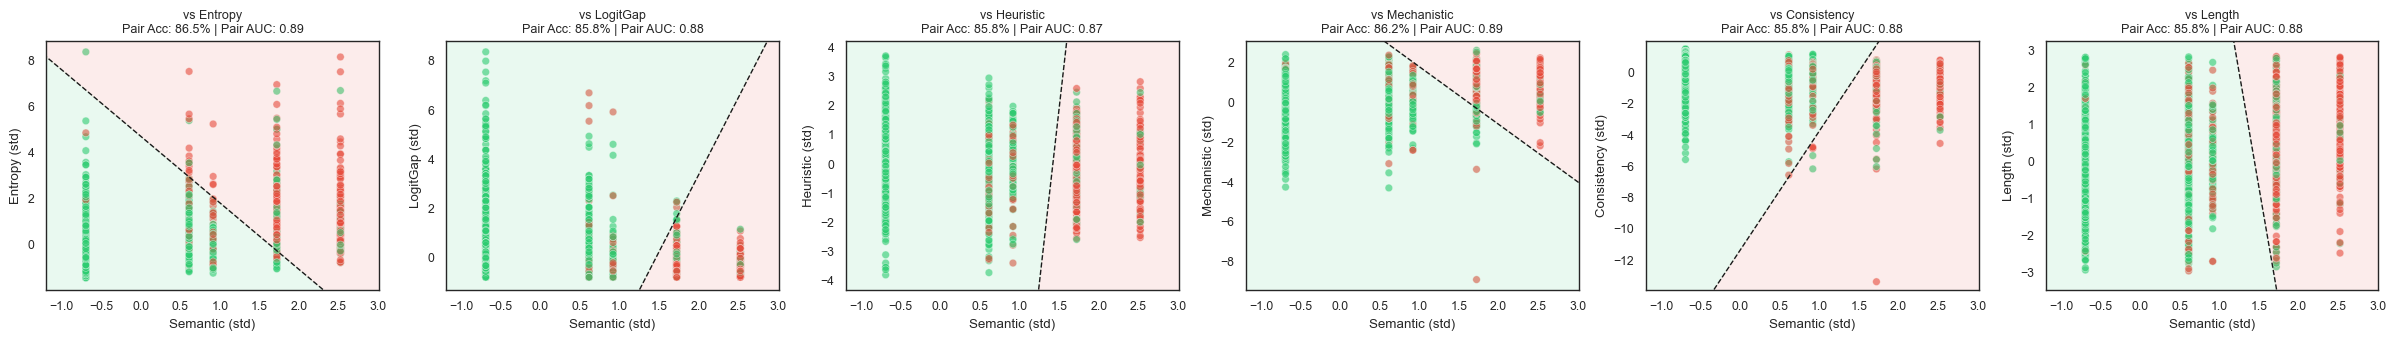

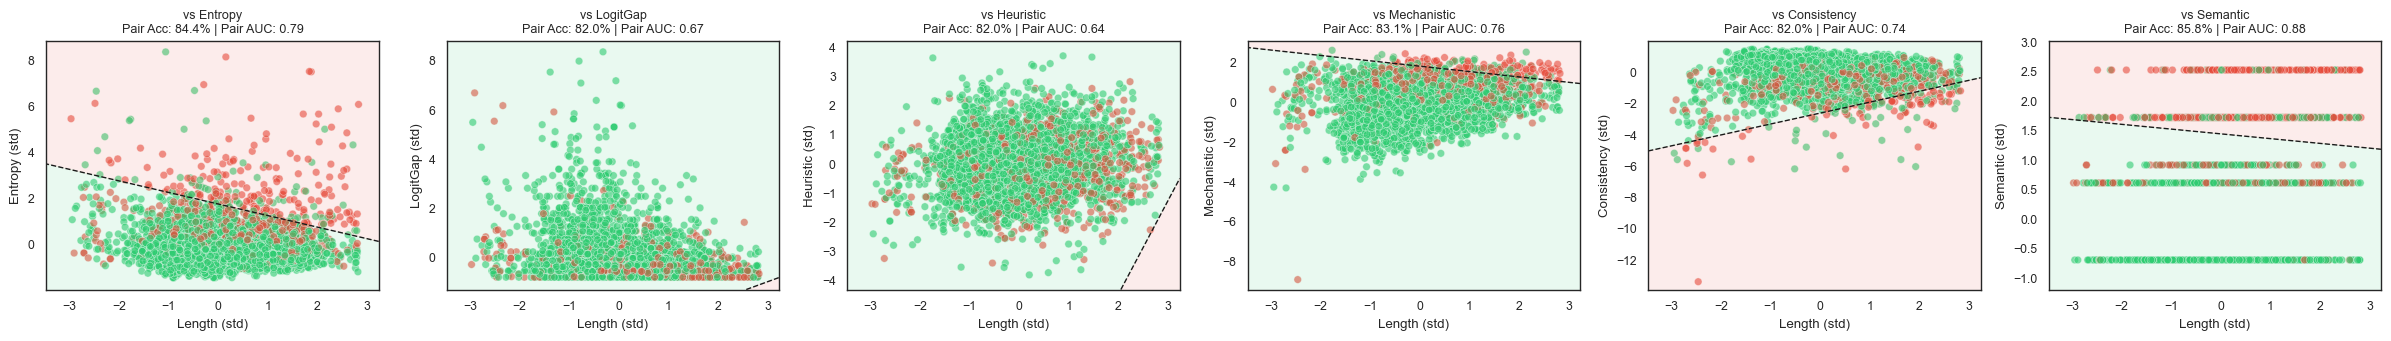

{'Entropy': <analysis_utils.PredictorArtifact at 0x33ead2010>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x35ddc46d0>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x3450f2d10>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x35e1da3d0>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x35dd226d0>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x33f0c0950>,
 'Length': <analysis_utils.PredictorArtifact at 0x34f452b50>}

In [4]:
utils.run_full_analysis(df,metrics)

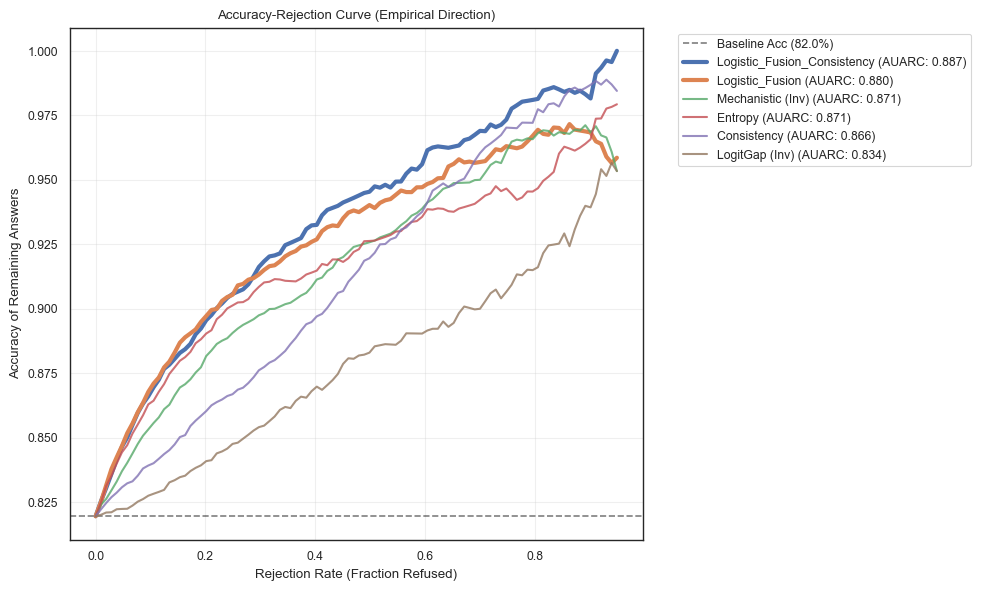

In [24]:
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

metrics_to_plot = ["Logistic_Fusion_Consistency", "Logistic_Fusion", "Mechanistic", "Entropy", "Consistency", "LogitGap"] 

utils.plot_auarc_analysis(df, metrics_to_plot)

In [6]:
df.keys()

Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency',
       'similarity_vector', 'uq_tokens', 'uq_mech_trace', 'uq_entropy_trace',
       'uq_logit_gap_trace', 'Correct', 'Semantic', 'Length', 'Entropy_Z',
       'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z', 'Consistency_Z',
       'Semantic_Z', 'Length_Z', 'Cluster', 'x', 'y', 'Logistic_Fusion',
       'Logistic_Fusion_Consistency', 'Cluster_Label', 'Cluster_Conf',
       'Logistic Fusion', 'Cluster Baseline'],
      dtype='object')

In [7]:
utils.analyze_outlier_clusters(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 30.3% - 97.6%
Analyzing 986 questions with multiple answers...


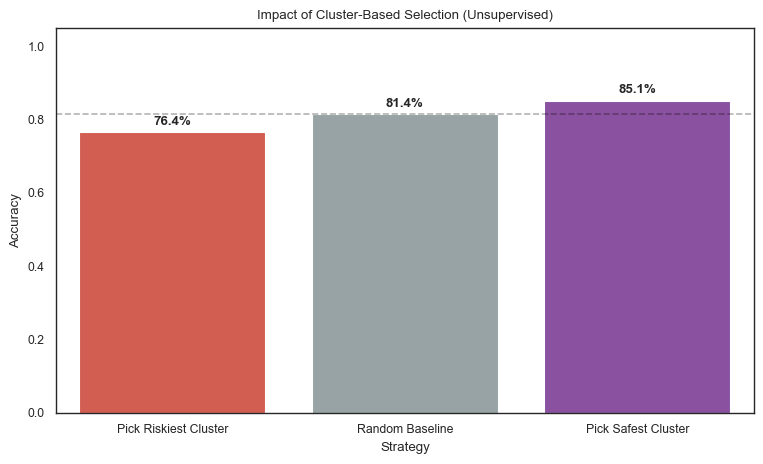

In [13]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)

🔍 Analyzing all 31 feature subsets...


,Feature,Impact,Verdict
4,Length,-1.87%,TOSS
2,Heuristic,-0.14%,TOSS
1,LogitGap,-0.03%,TOSS
3,Mechanistic,2.96%,KEEP
0,Entropy,4.99%,KEEP


,Size,Features,Acc_Best,Acc_Worst,Gap
0,2,"Entropy, LogitGap",86.1%,75.5%,10.6%
1,2,"Entropy, Heuristic",86.2%,75.7%,10.5%
2,4,"Entropy, LogitGap, Heuristic, Mechanistic",86.1%,75.7%,10.4%
3,1,Entropy,85.9%,75.5%,10.4%
4,3,"Entropy, LogitGap, Heuristic",86.1%,75.8%,10.3%


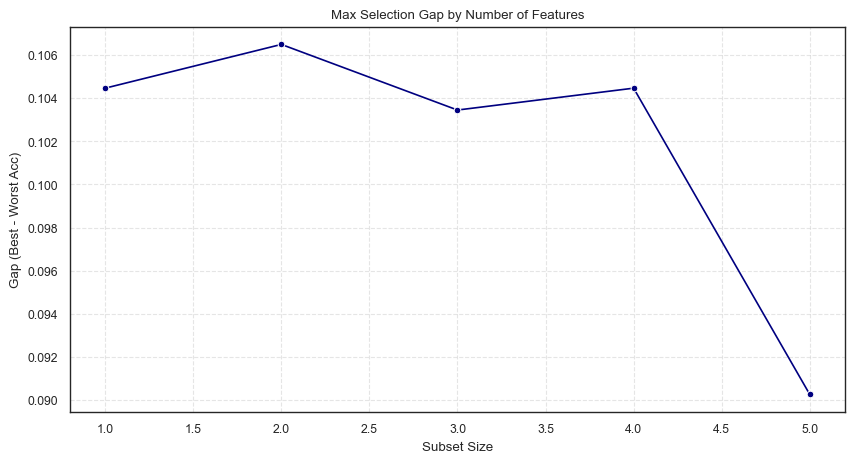

In [9]:
def analyze_feature_redundancy(df):
    import itertools
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from IPython.display import display, HTML
    
    # 1. Setup
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    results = []
    
    print(f"🔍 Analyzing all {2**len(features) - 1} feature subsets...")
    
    # Pre-scale to speed up the loop
    X_raw = df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=features, index=df.index)
    y = df['Correct']
    
    # Pre-filter for evaluation (Questions with multiple answers)
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    eval_mask = grouped[group_col].transform('count') > 1
    eval_df_base = df.loc[eval_mask, [group_col, 'Correct']].copy()
    
    if len(eval_df_base) == 0:
        print("⚠️ No multi-answer questions found to analyze.")
        return

    # 2. Brute-Force Search
    for r in range(1, len(features) + 1):
        for subset in itertools.combinations(features, r):
            cols = list(subset)
            
            # Train Fusion Model
            clf = LogisticRegression(class_weight='balanced', random_state=42)
            clf.fit(X_scaled[cols], y)
            
            # Predict
            probs = clf.predict_proba(X_scaled[cols])[:, 1]
            prob_series = pd.Series(probs, index=df.index)
            
            # Evaluate Selection Gap
            current_eval = eval_df_base.copy()
            current_eval['probs'] = prob_series[eval_mask]
            
            # Find best/worst per question
            g = current_eval.groupby(group_col)['probs']
            best_idx = g.idxmax()
            worst_idx = g.idxmin()
            
            # Only count questions where model actually distinguishes (Prob Best != Prob Worst)
            distinct_mask = current_eval.loc[best_idx, 'probs'].values != current_eval.loc[worst_idx, 'probs'].values
            
            valid_best = best_idx[distinct_mask]
            valid_worst = worst_idx[distinct_mask]
            
            if len(valid_best) > 0:
                acc_best = current_eval.loc[valid_best, 'Correct'].mean()
                acc_worst = current_eval.loc[valid_worst, 'Correct'].mean()
                gap = acc_best - acc_worst
                
                results.append({
                    'Size': len(cols),
                    'Features': ", ".join(cols),
                    'Acc_Best': acc_best,
                    'Acc_Worst': acc_worst,
                    'Gap': gap
                })

    # 3. Process Results
    res_df = pd.DataFrame(results).sort_values('Gap', ascending=False).reset_index(drop=True)
    
    # 4. Dispensability Analysis (Impact Score)
    # How much does the Gap drop when we REMOVE this feature?
    feature_impact = []
    for f in features:
        # Average Gap of subsets WITH feature f
        with_f = res_df[res_df['Features'].str.contains(f)]['Gap'].mean()
        # Average Gap of subsets WITHOUT feature f
        without_f = res_df[~res_df['Features'].str.contains(f)]['Gap'].mean()
        
        impact = with_f - without_f
        feature_impact.append({
            'Feature': f, 
            'Impact': impact,
            'Verdict': 'KEEP' if impact > 0.02 else ('BORDERLINE' if impact > 0 else 'TOSS')
        })
    
    impact_df = pd.DataFrame(feature_impact).sort_values('Impact', ascending=True)

    # --- DISPLAYS ---
    
    # A. Variable Impact Table
    html_impact = "<h3>🗑️ Variable Dispensability (Sorted by 'Freest to Throw Out')</h3>"
    html_impact += "<p><i>Low or Negative Impact = Removing this variable doesn't hurt (or helps).</i></p>"
    html_impact += impact_df.style.bar(subset=['Impact'], align='mid', color=['#e74c3c', '#27ae60'])\
        .format("{:.2%}", subset=['Impact'])\
        .to_html()
    display(HTML(html_impact))
    
    # B. Top Subsets Table
    html_top = "<h3>🏆 Top 5 Feature Combinations</h3>"
    html_top += res_df.head(5).style.background_gradient(subset=['Gap'], cmap='Greens')\
        .format("{:.1%}", subset=['Acc_Best', 'Acc_Worst', 'Gap'])\
        .to_html()
    display(HTML(html_top))

    # C. Complexity vs Performance Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=res_df, x='Size', y='Gap', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Max Selection Gap by Number of Features")
    plt.ylabel("Gap (Best - Worst Acc)")
    plt.xlabel("Subset Size")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- EXECUTE ---
analyze_feature_redundancy(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 30.3% - 97.6%
Analyzing 986 questions with multiple answers...


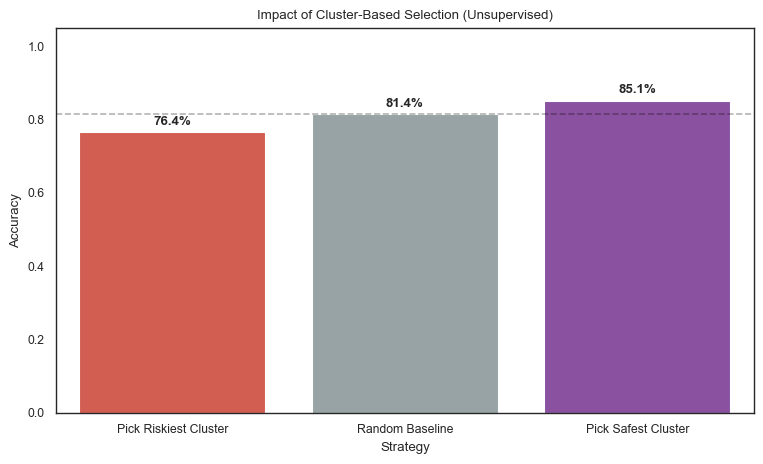

In [10]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)